# PROJET 5A - Préparation des Données (Pipeline Avancé)

**Objectif :** 
- Fusionner les données matchs et Elo,
- Appliquer un nettoyage intelligent (Fuzzy Matching) - Générer des sous-ensembles (basé sur taux de complétude)

**Entrées :** 
- `Matches.csv` 
- `EloRatings.csv` 

**Sorties :** 
- `Matches_with_Elo.csv`
- `matches_pred_full.csv`
- `matches_recent.csv`
- `matches_clean.csv`
- `matches_select_championnats.csv`

### IMPORTATIONS ET PARAMÈTRES GLOBAUX

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process

sys.path.append(os.getcwd())

try:
    import config as cfg
    print("Configuration chargée.")
    print(f"Dossier Entrée (Git) : {cfg.DATA_DIR_E}")
    print(f"Dossier Sortie (PC)  : {cfg.DATA_DIR_S}")
except ImportError:
    print("config.py introuvable")

DATA_DIR = cfg.DATA_DIR
MATCHES_PATH = cfg.FILE_MATCHES
ELO_PATH = cfg.FILE_ELO

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

print("Chargement des fichiers...")
matches = pd.read_csv(MATCHES_PATH, sep=";", parse_dates=["MatchDate"], dayfirst=True)
elo = pd.read_csv(ELO_PATH, sep=";")

print(f"Matches : {matches.shape}")
print(f"Elo : {elo.shape}")

Configuration chargée.
Dossier Entrée (Git) : C:\Users\Alban\Documents\IMDS\Projet_5A\Projet_5A_Prediction_matchs\Donnees
Dossier Sortie (PC)  : C:\Users\Alban\Documents\IMDS\Projet_5A\Donnees
Chargement des fichiers...


C:\Users\Alban\AppData\Local\Temp\ipykernel_4608\3374546584.py:27: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  matches = pd.read_csv(MATCHES_PATH, sep=";", parse_dates=["MatchDate"], dayfirst=True)


Matches : (228377, 42)
Elo : (242591, 4)


### EXPLORATION RAPIDE DES FICHIERS BRUTS

In [2]:
# Colonnes et aperçu
print("\nColonnes Matches :", matches.columns.tolist()[:10], "...")
print("Colonnes Elo :", elo.columns.tolist()[:10], "...")

nan_ratio = matches.isna().mean().sort_values(ascending=False)
print("\nTop 15 colonnes les plus incomplètes :")
print((nan_ratio * 100).head(15).round(1))


Colonnes Matches : ['Division', 'MatchDate', 'MatchTime', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away'] ...
Colonnes Elo : ['date', 'club', 'country', 'elo'] ...

Top 15 colonnes les plus incomplètes :
MatchTime      57.6
HomeTarget     51.1
AwayTarget     51.1
AwayFouls      51.0
HomeFouls      51.0
HomeCorners    50.9
AwayCorners    50.9
HomeShots      50.7
AwayShots      50.7
AwayRed        48.7
HomeYellow     48.7
AwayYellow     48.7
HomeRed        48.7
AwayElo        38.8
HomeElo        38.7
dtype: float64


### PRÉPARATION DES DONNÉES ELO

In [3]:
elo = elo.sort_values(["club", "date"]).reset_index(drop=True) # trie pour suivre temporalité

def compute_elo_change(df, months):
    """Ajoute la variation Elo sur 1, 3, 5 mois (snapshot 1er et 15)"""
    df[f"EloChange{months}M"] = df.groupby("club")["elo"].diff(periods=months*2) # calcul
    return df

for m in [1, 3, 6]: # application
    elo = compute_elo_change(elo, m)

elo = elo[["club", "date", "country", "elo", "EloChange1M", "EloChange3M", "EloChange6M"]]
print("Elo enrichi avec variations")

Elo enrichi avec variations


# -> peut etre faire ça après le matching plutôt ! 

### FUSION MATCHES - ELO (HOME / AWAY)

In [4]:
def merge_asof_team(matches_df, elo_df, team_col, prefix):
    """
    Associe à chaque match le dernier Elo connu du club avant la date du match
    """
    elo_cols_to_drop = {
        f"{prefix}EloSnap",
        f"{prefix}EloChange1M",
        f"{prefix}EloChange3M",
        f"{prefix}EloChange6M",
        f"{prefix}Elo_from_elo",          
        f"{prefix}Elo_from_elo_x",
        f"{prefix}Elo_from_elo_y",
    }

    # suppression en cas de doublon
    to_drop = [c for c in matches_df.columns if c in elo_cols_to_drop or c in {"date","date_x","date_y"}]
    left = matches_df.drop(columns=to_drop, errors="ignore").copy()   

    # colonnes essentielles
    rhs = (
        elo_df[["club", "date", "elo", "EloChange1M", "EloChange3M", "EloChange6M"]]
        .copy()
    )
    rhs.rename(columns={
        "club": team_col,
        "elo": f"{prefix}EloSnap",
        "EloChange1M": f"{prefix}EloChange1M",
        "EloChange3M": f"{prefix}EloChange3M",
        "EloChange6M": f"{prefix}EloChange6M",
    }, inplace=True)

    # fusion des 2 tables
    merged = pd.merge_asof(
        left.sort_values("MatchDate"),
        rhs.sort_values("date"),
        by=team_col,
        left_on="MatchDate",
        right_on="date",
        direction="backward",
        allow_exact_matches=True,
    )

    # Nettoyage
    merged.drop(columns=["date"], errors="ignore", inplace=True)
    return merged


# Bloc d’exécution 
matches["MatchDate"] = pd.to_datetime(matches["MatchDate"], dayfirst=True, errors="coerce")
elo["date"] = pd.to_datetime(elo["date"], dayfirst=True, errors="coerce")
matches = matches.sort_values("MatchDate")
elo = elo.sort_values(["club","date"]).reset_index(drop=True)

# Variations Elo 
for m in [1, 3, 6]:
    elo[f"EloChange{m}M"] = elo.groupby("club")["elo"].diff(periods=m*2)

# fusion pour 2 équipes
matches = merge_asof_team(matches, elo, "HomeTeam", "Home")
matches = merge_asof_team(matches, elo, "AwayTeam", "Away")

print("\nComplétude des Elo après merge_asof :")
print((matches[["HomeEloSnap", "AwayEloSnap"]].notna().mean() * 100).round(1))


Complétude des Elo après merge_asof :
HomeEloSnap    65.8
AwayEloSnap    65.8
dtype: float64


### FEATURE ENGINEERING (DIFFÉRENCES, PROBABILITÉS, FORMES)

In [5]:
# --- Différences Elo
matches["EloDiff"] = matches["HomeEloSnap"] - matches["AwayEloSnap"]
matches["EloTotal"] = matches["HomeEloSnap"] + matches["AwayEloSnap"]
matches["EloAdvantage"] = matches["EloDiff"] / matches["EloTotal"]

# --- Formes et momentum
matches["Form3Diff"] = matches["Form3Home"] - matches["Form3Away"]
matches["Form5Diff"] = matches["Form5Home"] - matches["Form5Away"]
matches["FormMomentumHome"] = matches["Form3Home"] - (matches["Form5Home"] - matches["Form3Home"])
matches["FormMomentumAway"] = matches["Form3Away"] - (matches["Form5Away"] - matches["Form3Away"])

# --- Probabilités implicites
for col in ["Home","Draw","Away"]:
    matches[f"P{col}"] = 1 / matches[f"Odd{col}"]

matches["ProbSum"] = matches["PHome"] + matches["PDraw"] + matches["PAway"]
for col in ["Home","Draw","Away"]:
    matches[f"P{col}_norm"] = matches[f"P{col}"] / matches["ProbSum"]

# --- Indices de match
matches["ShotsDifference"] = matches["HomeShots"] - matches["AwayShots"]
matches["CornersDifference"] = matches["HomeCorners"] - matches["AwayCorners"]
matches["CardsHome"] = matches["HomeYellow"] + 2*matches["HomeRed"]
matches["CardsAway"] = matches["AwayYellow"] + 2*matches["AwayRed"]
matches["CardsDiff"] = matches["CardsHome"] - matches["CardsAway"]
matches["GameDominanceIndex"] = (matches["ShotsDifference"] + matches["CornersDifference"]) / 2

print("Features créées")

Features créées


In [6]:
cols = ["EloDiff", "EloTotal", "EloAdvantage"]

before_completion = matches[cols].notna().mean() * 100
print("\nComplétude avant recalcul :")
print(before_completion)


Complétude avant recalcul :
EloDiff         59.47972
EloTotal        59.47972
EloAdvantage    59.47972
dtype: float64


### GÉNÉRATION DES MAPPINGS (DIVISION - PAYS)

In [7]:
template_path = cfg.FILE_MERGE_COUNTRY

if not template_path.exists():
    divisions = sorted(matches["Division"].dropna().unique())
    pd.DataFrame({"Division": divisions, "CountryCode": [""] * len(divisions)}).to_csv(template_path, index=False)
    print(" Template généré :", template_path)
else:
    print("Template déjà présent")

Template déjà présent


### FUZZY-MATCHING DES CLUBS MANQUANTS 
##### Objectif :
##### - Identifier les clubs des matches non trouvés dans EloRatings
##### - Trouver automatiquement les correspondances les plus probables
##### - Sauvegarder les mappings pour corrections manuelles si besoin

In [8]:
RUN_FUZZY_MAPPING = False  

if RUN_FUZZY_MAPPING:

    # vérif fichiers 
    SUGGEST_PATH = cfg.FILE_MAPPING_SUGGEST
    CLEAN_PATH = cfg.FILE_MAPPING_CLEAN

    if CLEAN_PATH.exists():
        print("Mapping déjà présent :", CLEAN_PATH)
    else:

        # Chargement 
        # liaison div et pays manuelle
        divmap = pd.read_csv(cfg.FILE_MERGE_COUNTRY, sep=",") 
        elo_full = pd.read_csv(ELO_PATH, sep=";")

        # restreint fuzzy matching au pays (évite les erreurs)
        matches["Country"] = matches["Division"].map(dict(zip(divmap["Division"], divmap["CountryCode"])))
        matches_elo = matches[matches["Country"].isin(elo_full["country"].unique())].copy()

        print(f"Matchs initiaux : {len(matches)}")
        print(f"Matchs avec Elo disponible : {len(matches_elo)} ({len(matches_elo)/len(matches):.1%})")

        # Clubs manquants
        missing_clubs = set(matches[matches["HomeEloSnap"].isna()]["HomeTeam"].unique()) | \
                        set(matches[matches["AwayEloSnap"].isna()]["AwayTeam"].unique())

        # Fuzzy matching avec RapidFuzz 
        elo_clubs = elo_full["club"].unique()
        suggestions = []

        # pour chaque club avec NaN, on retient 3 pays candidats pour etre identiques
        # à mettre dans suggestions
        for club in sorted(missing_clubs):
            possible_countries = matches.loc[matches["HomeTeam"]==club, "Country"].dropna().unique().tolist()
            if not possible_countries:
                possible_countries = matches.loc[matches["AwayTeam"]==club, "Country"].dropna().unique().tolist()

            if possible_countries:
                possible_elo = elo_full[elo_full["country"].isin(possible_countries)]["club"].unique()
            else:
                possible_elo = elo_clubs

            best_matches = process.extract(club, possible_elo, limit=3)
            for match, score, _ in best_matches:
                suggestions.append({
                    "club_missing": club,
                    "suggested_match": match,
                    "similarity": score,
                    "countries_considered": ", ".join(possible_countries) if possible_countries else "ALL"
                })
        # filtre les mauvaises suggestions
        suggestions_df = pd.DataFrame(suggestions)
        suggestions_df = suggestions_df[
            (suggestions_df["countries_considered"].notna()) &
            (suggestions_df["countries_considered"] != "ALL")
        ]
        # on garde le meilleur
        best_suggestions = (
            suggestions_df.sort_values(["club_missing", "similarity"], ascending=[True, False])
            .groupby("club_missing").head(1)
        )
        # sauvegarde
        best_suggestions.to_csv(SUGGEST_PATH, index=False)
        print("Suggestions sauvegardées :", SUGGEST_PATH)

        # on garde similarity > 85%
        mapping_filtered = best_suggestions[best_suggestions["similarity"] >= 85].copy()
        mapping_filtered = (
            mapping_filtered.sort_values("similarity", ascending=False)
            .drop_duplicates("club_missing")
        )
        mapping_filtered.to_csv(CLEAN_PATH, index=False)
        print(f"Mapping propre sauvegardé ({len(mapping_filtered)} correspondances) :", CLEAN_PATH)

    # Application du mapping 
    mapping_df = pd.read_csv(CLEAN_PATH)
    club_mapping = dict(zip(mapping_df["club_missing"], mapping_df["suggested_match"]))
    matches["HomeTeam"] = matches["HomeTeam"].replace(club_mapping)
    matches["AwayTeam"] = matches["AwayTeam"].replace(club_mapping)

    print("Mapping des clubs appliqué")

else:
    print("Fuzzy-matching désactivé")

Fuzzy-matching désactivé


### SAUVEGARDE SÉCURISÉE DU FICHIER PRINCIPAL

In [9]:
save_path = cfg.FILE_MATCHES_ELO

if not save_path.exists():
    matches.to_csv(save_path, sep=";", index=False)
    print("Matches_with_Elo.csv sauvegardé")
else:
    print("Fichier déjà existant")

Fichier déjà existant


### COHÉRENCE DES ELO

In [10]:
import random

matches = pd.read_csv(cfg.FILE_MATCHES_ELO, sep=";")

# voir si bien format datetime pour la comparaison
matches["MatchDate"] = pd.to_datetime(matches["MatchDate"], errors="coerce")
elo["date"] = pd.to_datetime(elo["date"], errors="coerce")

# 10 clubs au hasard pris
#-----------------------------------------------
# PEUT ETRE PRENDRE QUE CEUX AVEC FUZZY MATCHING
#-----------------------------------------------
clubs = random.sample(matches["HomeTeam"].dropna().unique().tolist(), 10)
print("\nVérif sur 10 clubs aléatoires :")

# vérification pour ces cas en comparant elosnap et valeur de référence
for club in clubs:
    match_row = matches[matches["HomeTeam"] == club].sample(1, random_state=1)
    match_date = match_row["MatchDate"].values[0]
    match_elo = match_row["HomeEloSnap"].values[0]
    elo_club = elo[elo["club"] == club]
    elo_before = elo_club[elo_club["date"] <= match_date].tail(1)
    if not elo_before.empty:
        real_elo = elo_before["elo"].values[0]
        delta = match_elo - real_elo
        print(f"{club:25s} | ΔElo = {delta:+.1f}")

C:\Users\Alban\AppData\Local\Temp\ipykernel_4608\4196789793.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches["MatchDate"] = pd.to_datetime(matches["MatchDate"], errors="coerce")



Vérif sur 10 clubs aléatoires :
Umraniyespor              | ΔElo = +0.0
Bolton                    | ΔElo = +0.0
Quevilly Rouen            | ΔElo = +0.0
Erzurum BB                | ΔElo = +0.0
Lamia                     | ΔElo = +0.0
Ajax                      | ΔElo = +0.0
Egaleo                    | ΔElo = +0.0
Ternana                   | ΔElo = +0.0
CFR Cluj                  | ΔElo = +0.0
Aston Villa               | ΔElo = +0.0


In [11]:
coverage = matches[["HomeEloSnap", "AwayEloSnap"]].notna().mean() * 100
print("\nComplétude finale des Elo dans Matches :")
print(coverage)


Complétude finale des Elo dans Matches :
HomeEloSnap    97.282920
AwayEloSnap    91.580072
dtype: float64


### GÉNÉRATION DES SOUS-DATASETS

In [12]:
# désactivé
REGENERATE_SUBSETS = False  
SUBSETS = [
    "matches_pred_full.csv",
    "matches_recent.csv",
    "matches_clean.csv",
    "matches_select_championnats.csv"
]

if REGENERATE_SUBSETS:

    df = matches.copy()
    # regroupe par saison
    df["Season"] = pd.to_datetime(df["MatchDate"], errors="coerce").dt.year

    print(f"Dataset initial : {len(df):,} lignes, {df.shape[1]} colonnes")

    cols_target = ["FTResult"]  
    cols_id = ["Division", "MatchDate", "HomeTeam", "AwayTeam"]

    # on ne prend pas en compte dans la prédiction d'avant match
    cols_post = [
        "FTHome", "FTAway", "FTResult", "HTHome", "HTAway", "HTResult",
        "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
        "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
        "HomeYellow", "AwayYellow", "HomeRed", "AwayRed",
        "CardsHome", "CardsAway", "CardsDiff",
        "GameDominanceIndex", "ShotsDifference", "CornersDifference"
    ]
    cols_post = [c for c in cols_post if c in df.columns]

    def filter_features(df, min_notna_ratio=0.7, exclude_postmatch=True):
        """Filtre les colonnes selon un seuil minimal de complétude"""
        na_ratio = df.isna().mean()
        keep_cols = na_ratio[na_ratio <= 1 - min_notna_ratio].index.tolist()
        if exclude_postmatch:
            keep_cols = [c for c in keep_cols if c not in cols_post]
        return keep_cols

    # sauvegarde des sous dataset avec cette fonction
    def save_version(df, name):
        path = cfg.DATA_DIR_S / name
        df.to_csv(path, index=False, sep=";") 
        print(f" {name} sauvegardé ({len(df):,} lignes, {df.shape[1]} colonnes)")
        return path

    # garde les colonnes avec plus de 70% de complétude
    cols_pred = filter_features(df, min_notna_ratio=0.7)
    df_pred_full = df[cols_id + cols_pred + cols_target].drop_duplicates()
    save_version(df_pred_full, "matches_pred_full.csv")

    # matches_recent 
    min_threshold_recent = 0.8
    compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
    valid_seasons_recent = compl_by_season[compl_by_season >= min_threshold_recent].index
    year_min_recent = valid_seasons_recent.min() if len(valid_seasons_recent) > 0 else df["Season"].min()

    df_recent = df[df["Season"] >= year_min_recent].copy()
    cols_recent = filter_features(df_recent, min_notna_ratio=min_threshold_recent)
    df_recent_f = df_recent[cols_id + cols_recent + cols_target]
    save_version(df_recent_f, "matches_recent.csv")
    print(f" matches_recent : saisons ≥ {year_min_recent} (complétude moyenne ≥ {min_threshold_recent*100:.0f}%)")

    # matches_clean
    min_threshold_clean = 0.9
    compl_by_season_clean = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
    valid_seasons_clean = compl_by_season_clean[compl_by_season_clean >= min_threshold_clean].index
    year_min_clean = valid_seasons_clean.min() if len(valid_seasons_clean) > 0 else df["Season"].min()

    df_clean = df[df["Season"] >= year_min_clean].copy()
    cols_clean = filter_features(df_clean, min_notna_ratio=min_threshold_clean)
    df_clean_f = df_clean[cols_id + cols_clean + cols_target]
    save_version(df_clean_f, "matches_clean.csv")
    print(f" matches_clean : saisons ≥ {year_min_clean} (complétude moyenne ≥ {min_threshold_clean*100:.0f}%)")

    # matches_select_championnats
    THRESHOLD_COL = 0.8
    THRESHOLD_SEASON = 0.8
    THRESHOLD_DIV = 0.8

    na_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())
    valid_seasons = na_by_season[na_by_season >= THRESHOLD_SEASON].index.tolist()
    na_by_div = 1 - df.groupby("Division").apply(lambda x: x.isna().mean().mean())
    valid_divs = na_by_div[na_by_div >= THRESHOLD_DIV].index.tolist()

    df_select = df[df["Season"].isin(valid_seasons) & df["Division"].isin(valid_divs)].copy()
    na_ratio_cols = df_select.isna().mean()
    valid_cols = na_ratio_cols[na_ratio_cols <= 1 - THRESHOLD_COL].index.tolist()
    valid_cols = [c for c in valid_cols if c not in cols_post]

    df_select = df_select[cols_id + valid_cols + cols_target].drop_duplicates().reset_index(drop=True)
    save_version(df_select, "matches_select_championnats.csv")

else:
    print("Sous-datasets déjà générés")

    paths = [cfg.DATA_DIR_S / f for f in SUBSETS]
    df_pred_full, df_recent_f, df_clean_f, df_select = [pd.read_csv(p, sep=";") for p in paths]

# résumé
summary = pd.DataFrame({
    "Dataset": ["matches_pred_full", "matches_recent", "matches_clean", "matches_select_championnats"],
    "Seuil complétude": ["≥70%", "≥80% (auto années)", "≥90% (auto années)", "≥80% (auto ligues/colonnes)"],
    "Nb lignes": [len(df_pred_full), len(df_recent_f), len(df_clean_f), len(df_select)],
    "Nb colonnes": [df_pred_full.shape[1], df_recent_f.shape[1], df_clean_f.shape[1], df_select.shape[1]],
    "Complétude moyenne (%)": [
        100 * (1 - df_pred_full.isna().mean().mean()),
        100 * (1 - df_recent_f.isna().mean().mean()),
        100 * (1 - df_clean_f.isna().mean().mean()),
        100 * (1 - df_select.isna().mean().mean())
    ]
}).round(1)

print("\nRésumé des datasets disponibles :")
print(summary)

Sous-datasets déjà générés

Résumé des datasets disponibles :
                       Dataset             Seuil complétude  Nb lignes  \
0            matches_pred_full                         ≥70%     165619   
1               matches_recent           ≥80% (auto années)     138312   
2                matches_clean           ≥90% (auto années)       8478   
3  matches_select_championnats  ≥80% (auto ligues/colonnes)      52580   

   Nb colonnes  Complétude moyenne (%)  
0           48                    92.2  
1           46                    94.7  
2           35                    98.5  
3           48                    97.3  


### SYNTHÈSE ET VISUALISATION

C:\Users\Alban\AppData\Local\Temp\ipykernel_4608\3501722147.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())


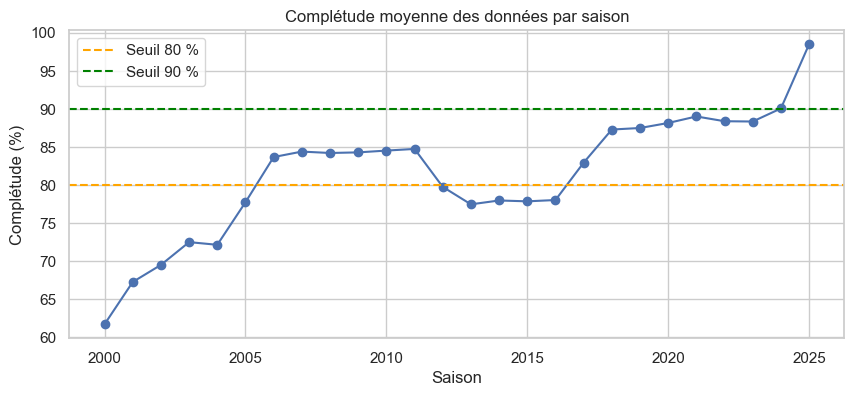

In [13]:
df = matches.copy()
df["Season"] = pd.to_datetime(df["MatchDate"], errors="coerce").dt.year
compl_by_season = 1 - df.groupby("Season").apply(lambda x: x.isna().mean().mean())

plt.figure(figsize=(10,4))
plt.plot(compl_by_season.index, compl_by_season.values*100, marker='o')
plt.axhline(80, color='orange', linestyle='--', label='Seuil 80 %')
plt.axhline(90, color='green', linestyle='--', label='Seuil 90 %')
plt.title("Complétude moyenne des données par saison")
plt.xlabel("Saison")
plt.ylabel("Complétude (%)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
cols = ["EloDiff", "EloTotal", "EloAdvantage"]

after_completion = matches[cols].notna().mean() * 100
print("\nComplétude après recalcul :")
print(after_completion)


Complétude après recalcul :
EloDiff         90.633321
EloTotal        90.633321
EloAdvantage    90.633321
dtype: float64
